In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scanpy as sc
import muon as mu
import builtins #this is because np is shadowing built in sum but can be overwritten using builtins

mpl.rcParams.update({
    # --- Fonts: keep text editable ---
    'pdf.fonttype': 'truetype',   # same as 42, ensures TrueType fonts
    'ps.fonttype': 'truetype',    # for EPS compatibility
    'svg.fonttype': 'none',       # keeps SVG text as text, not outlines

    # --- PDF structure: keep elements separate ---
    'pdf.compression': 0,         # prevents grouping/merging of vector paths
    'savefig.transparent': True,  # optional: preserves transparent backgrounds
    'savefig.bbox': 'tight',      # trims whitespace
    'savefig.pad_inches': 0.02,   # small padding for Illustrator bleed safety

    # --- General style niceties ---
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.family': 'sans-serif'
})

from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

In [2]:
#Variable, settings, colors

In [3]:
#Variables
lclusters = ['2','6','17','21','5','16','12', '1','11','24','4','0','19','3', '10', '7','15','23','18',  '14', '8', '20', '22', '13','9'] #ordered cluster list
lclusters_int = [int(i) for i in lclusters]

devcell_types = ['HSC', 'MPP1','MPP2','LMPP', 'Neu1', 'Neu2', 'MD', 'EBM','Mk','MEP','Ery', 'MLP', 'B_NK1', 'B_NK2'] #Note a few cells map to lymphoid

In [4]:
#Plot settings
bar_width = 0.75

In [9]:
#colors
colors_sheet = pd.read_excel('../data/production_color_v1.xlsx') #test sheet

#make leiden cluster color dictionary
colors_dict = dict(zip(colors_sheet.leiden, colors_sheet.colour))

#make DevCell color dictionary
dc_colors_dict = {}
for k, v in dict(zip(colors_sheet.DevCell, colors_sheet.DC_color)).items():
    if isinstance(k, str):
        dc_colors_dict[k] = v

#make Patient color dictionary
pat_colors_dict = {}
for k, v in dict(zip(colors_sheet.Patient, colors_sheet.Patient_color)).items():
    if isinstance(k, str):
        pat_colors_dict[k] = v

#make Patient color dictionary - extra version as one will be updated later
pat_colors_dict2 = {}
for k, v in dict(zip(colors_sheet.Patient, colors_sheet.Patient_color)).items():
    if isinstance(k, str):
        pat_colors_dict2[k] = v

#make sequencing batch color dictionary
batch_colors_dict = {}
for k, v in dict(zip(colors_sheet.Pool, colors_sheet.Pool_color)).items():
    if isinstance(k, str):
        batch_colors_dict[k] = v

In [11]:
#1. DevCell annotations

In [13]:
#Import DevCell assignments
dcl = pd.read_csv('../Data/celltype_annotation_full.csv')
#dcl

In [15]:
#devcell proportion per cluster
dc_props = None

for c in lclusters_int:
    dcl_sub = dcl.loc[dcl['leiden_cluster'] == c]
    
    # Calculate proportions of each cell type
    df = pd.DataFrame(dcl_sub['devcell'].value_counts(normalize=True) * 100).reset_index()
    df['leiden'] = int(c)

    if dc_props is None:
        dc_props = df.copy()
    else:
        dc_props = pd.concat([dc_props, df],ignore_index = True)
 
#dc_props

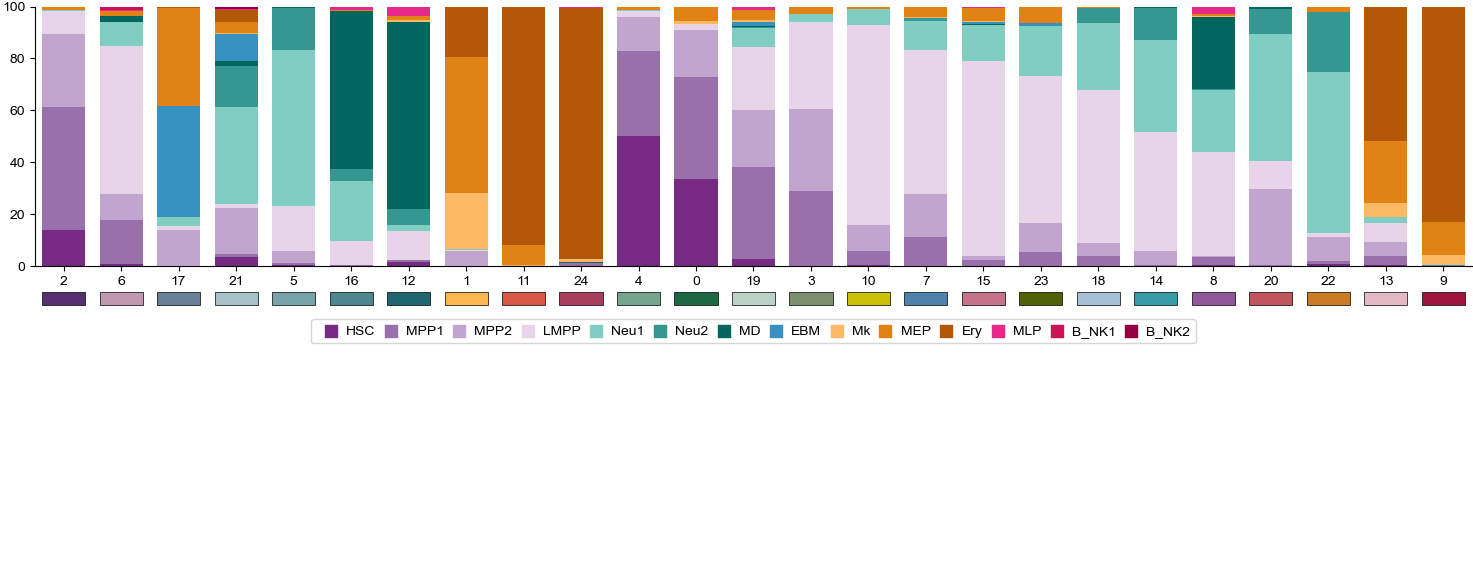

In [17]:
#devcell annotation representation in each cluster
fig, ax = plt.subplots(2,1, figsize = (15, 6))
ax = ax.ravel()

plot_cols = dc_colors_dict

for i, c in enumerate(lclusters_int):
    
        df = dc_props.loc[(dc_props['leiden']==c)]
        # Sum of all proportions = total bar height
        total_height = df['proportion'].sum()
        #Turn df into a dictionary
        proportion_dict = dict(zip(df.devcell, df.proportion))
        #plot the bar graphs
        bottom = 0
        for category in devcell_types:
            height = proportion_dict.get(category, 0)
            color = plot_cols[category]
            ax[0].bar(i,
                     height,
                     bar_width,
                     bottom = bottom,
                     color = color)
            
            bottom += height #update bottom value for next plot
            
        # --- Add color squares above top row ---
        square_y = -15
        square_size = bar_width
        color = colors_dict.get(int(c), 'lightgrey')
        rect = mpatches.Rectangle(
            (i - square_size / 2, square_y),
            width=square_size,
            height=5,
            facecolor=color,
            edgecolor='k',
            lw=0.5,
            zorder=15,
            clip_on=False,
            transform=ax[0].transData
        )
        ax[0].add_patch(rect)

ax[0].set_ylim(0,100)
ax[0].set_xlim(-0.5, 24.5)
ax[0].set_xticks(np.arange(0,25, 1))
ax[0].set_xticklabels(lclusters)
ax[0].spines['top'].set_visible(False) 
ax[0].spines['right'].set_visible(False) 

#Proxy artist for legend
leg_pal = {}
for m in devcell_types:
    leg_pal[m] = plot_cols[m] 
    
handles = []
f, a = plt.subplots()

for lab in leg_pal.keys():
    line = a.scatter([0], [0], label=lab, color=leg_pal[lab], marker = 's', s = 80,  linewidth = 1)
    handles.append(line)    
plt.close(f)

ax[1].legend(handles = handles, labels = leg_pal.keys(), loc = 'upper center',bbox_to_anchor = [0.5,1], ncol = 14, columnspacing = 0.1, handletextpad=0.1, markerscale = 1)
ax[1].set_axis_off()

fig.tight_layout()
#fig.savefig('../Figures/1_Devcell_annotation_leiden_barplots_v1_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

In [19]:
#2. Patient source annotations

In [21]:
#Read in data from master h5mu file created for GEO upload
adata = mu.read_h5ad('../Data/GEO_data_file_v1.h5mu', mod = 'rna')
print(adata.shape)
adata_all = adata.obs.copy() 

(38231, 28762)


In [22]:
adata

AnnData object with n_obs × n_vars = 38231 × 28762
    obs: 'BARCODE', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'timepoint', 'leiden', 'patient_alias', 'TP53_p.Cys238Tyr', 'TP53_p.Pro177His', 'category', 'capture_pool', 'singleR_annotation', 'time', 'inferCNV_cluster', 'SNPmani_cluster'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'chromosome', 'gene', 'start', 'end'
    uns: 'capture_pool_colors', 'cnv', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'patient_alias_colors', 'pca', 'rank_genes_groups', 'singleR_annotation_colors', 'umap'
    obsm: 'X_cnv', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [25]:
#Add devcell annotations to the adata.obs 
dcl_dict = dict(zip(dcl['Unnamed: 0'], dcl['devcell']))
adata.obs['devcell'] = adata.obs['singleR_annotation'] #column called 'singleR_annotation' in updated master h5mu
#adata.obs

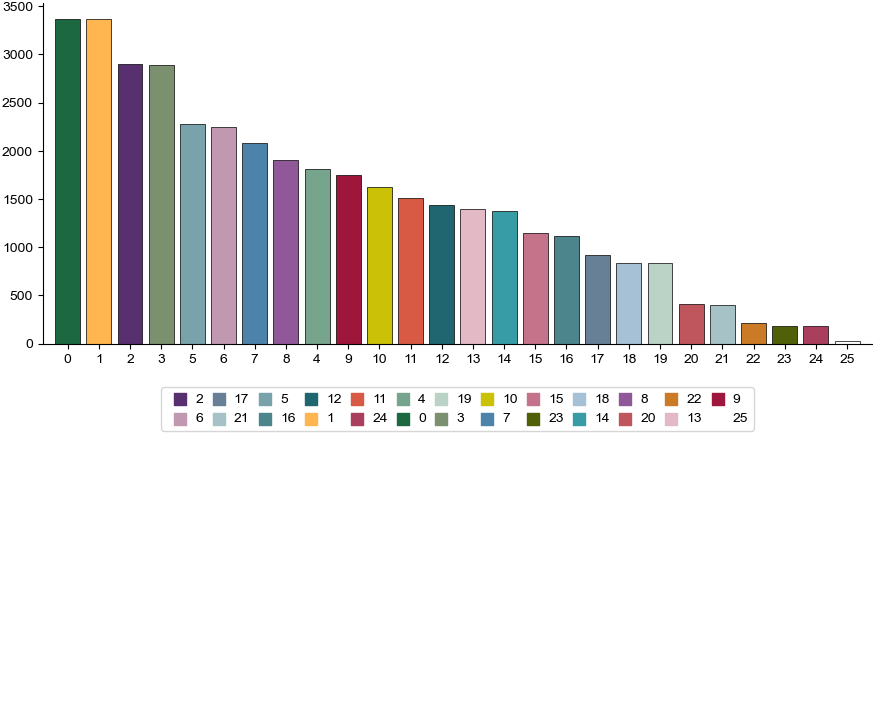

In [27]:
#Plot cluster size
cl_freq = adata_all['leiden'].value_counts()

fig, ax = plt.subplots(2,1, figsize = (9,7.5))
ax = ax.ravel()

plot_cols = colors_dict

for x, y in cl_freq.items():
    ax[0].bar(x,y, color = plot_cols[int(x)], edgecolor = 'k', linewidth = 0.5)

ax[0].set_xlim(-0.8, 25.8)
ax[0].spines['top'].set_visible(False) 
ax[0].spines['right'].set_visible(False) 

#Proxy artist for legend
leg_pal = {}
for m in lclusters_int:
    leg_pal[m] = plot_cols[m] 
leg_pal[25] = plot_cols[25] 

handles = []
f, a = plt.subplots()

for lab in leg_pal.keys():
    line = a.scatter([0], [0], label=lab, color=leg_pal[lab], marker = 's', s = 80,  linewidth = 1)
    handles.append(line)    
plt.close(f)

ax[1].legend(handles = handles, labels = leg_pal.keys(), loc = 'upper center',bbox_to_anchor = [0.5,1], ncol = 13, columnspacing = 0.1, handletextpad=0.1, markerscale = 1)
ax[1].set_axis_off()

fig.tight_layout()
#fig.savefig('../Figures/1_nCells_per_cluster_v2_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

In [29]:
#How many cells in each cluster?
adata_all['leiden'].value_counts()

leiden
0     3367
1     3363
2     2901
3     2889
5     2280
6     2250
7     2083
8     1901
4     1810
9     1753
10    1629
11    1510
12    1440
13    1396
14    1375
15    1149
16    1114
17     919
18     841
19     835
20     406
21     404
22     217
23     187
24     186
25      26
Name: count, dtype: int64

In [31]:
#How many healthy cells in each cluster?
h_num = dict(zip(pd.DataFrame(adata_all.loc[adata_all['patient_alias'].isin(['C1', 'C2', 'C3', 'C4', 'C5'])]['leiden'].value_counts()).reset_index()['leiden'], 
        pd.DataFrame(adata_all.loc[adata_all['patient_alias'].isin(['C1', 'C2', 'C3', 'C4', 'C5'])]['leiden'].value_counts()).reset_index()['count']))
h_num

{'6': 174,
 '1': 135,
 '2': 119,
 '12': 52,
 '5': 38,
 '11': 36,
 '16': 22,
 '24': 12,
 '21': 12,
 '17': 7,
 '0': 0,
 '23': 0,
 '22': 0,
 '20': 0,
 '19': 0,
 '18': 0,
 '13': 0,
 '15': 0,
 '14': 0,
 '10': 0,
 '9': 0,
 '8': 0,
 '7': 0,
 '4': 0,
 '3': 0,
 '25': 0}

In [33]:
#patient proportion per cluster
l_props = None

 
for c in lclusters:
    dfa = adata_all.loc[adata_all['leiden'] == c]
    
    # Calculate proportions of each cell type
    df = pd.DataFrame(dfa['patient_alias'].value_counts(normalize=True) * 100).reset_index()
    df['leiden'] = c


    if l_props is None:
        l_props = df.copy()
    else:
        l_props = pd.concat([l_props, df],ignore_index = True)

#l_props

In [35]:
#patient proportion per cluster - just healthy donors
l_props_h = None

 
for c in lclusters:
    dfa = adata_all.loc[(adata_all['leiden'] == c) & (adata_all['patient_alias'].isin(['C1', 'C2', 'C3', 'C4', 'C5']))]
    
    # Calculate proportions of each cell type
    df = pd.DataFrame(dfa['patient_alias'].value_counts(normalize=True) * 100).reset_index()
    df['leiden'] = c

    if l_props_h is None:
        l_props_h = df.copy()
    else:
        l_props_h = pd.concat([l_props_h, df],ignore_index = True)

#l_props_h

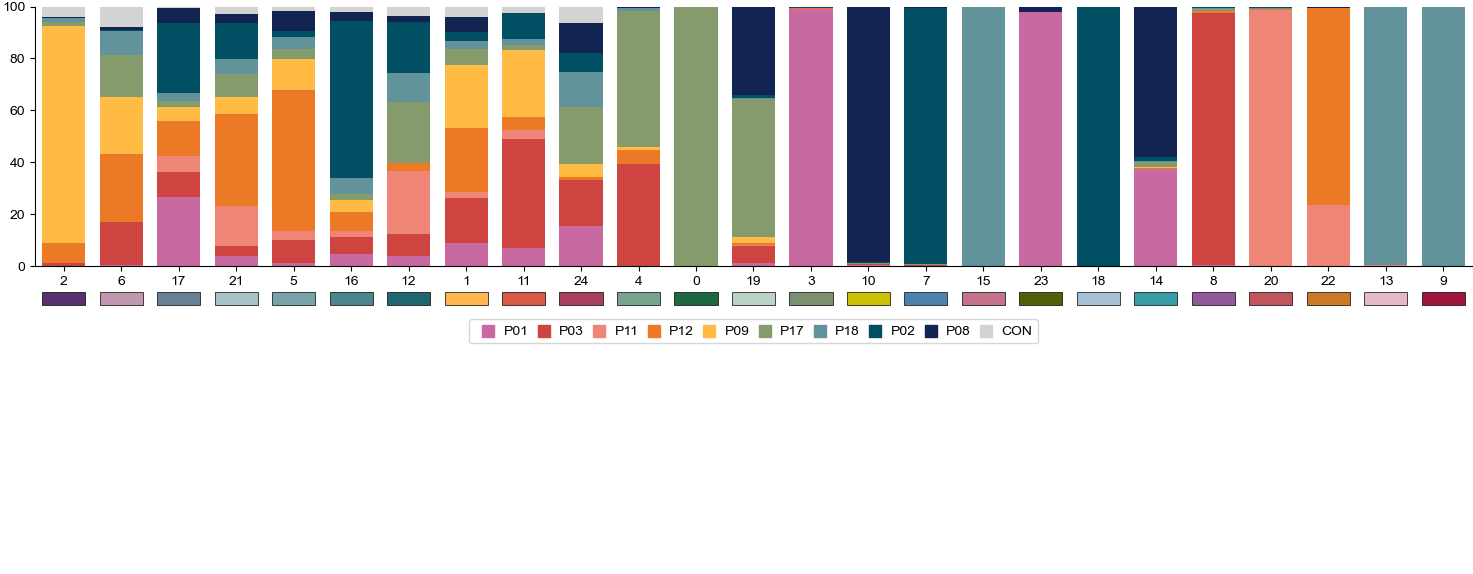

In [37]:
#patient annotation representation in each cluster
fig, ax = plt.subplots(2,1, figsize = (15, 6))
ax = ax.ravel()

plot_cols = pat_colors_dict

for i, c in enumerate(lclusters):
    
        df = l_props.loc[(l_props['leiden']==c) & (l_props['patient_alias'].isin(['P01', 'P03', 'P11', 'P12', 'P09', 'P17', 'P18',  'P02', 'P08', 'C1', 'C2', 'C3', 'C4', 'C5']))]
        # Sum of all proportions = total bar height
        total_height = df['proportion'].sum()
        #Turn df into a dictionary
        proportion_dict = dict(zip(df.patient_alias, df.proportion))
        #plot the bar graphs
        bottom = 0
        for category in ['P01', 'P03', 'P11', 'P12', 'P09', 'P17', 'P18',  'P02', 'P08', 'C1', 'C2', 'C3', 'C4', 'C5']:
            height = proportion_dict.get(category, 0)
            color = plot_cols[category]
            ax[0].bar(i,
                     height,
                     bar_width,
                     bottom = bottom,
                     color = color)
            
            bottom += height #update bottom value for next plot

        # --- Add color squares above top row ---
        square_y = -15
        square_size = bar_width
        color = colors_dict.get(int(c), 'lightgrey')
        rect = mpatches.Rectangle(
            (i - square_size / 2, square_y),
            width=square_size,
            height=5,
            facecolor=color,
            edgecolor='k',
            lw=0.5,
            zorder=15,
            clip_on=False,
            transform=ax[0].transData
        )
        ax[0].add_patch(rect)

ax[0].set_ylim(0,100)
ax[0].set_xlim(-0.5, 24.5)
ax[0].set_xticks(np.arange(0,25, 1))
ax[0].set_xticklabels(lclusters)
ax[0].spines['top'].set_visible(False) 
ax[0].spines['right'].set_visible(False) 

#Proxy artist for legend
leg_pal = {}
for m in ['P01', 'P03', 'P11', 'P12', 'P09', 'P17', 'P18',  'P02', 'P08']:
    leg_pal[m] = plot_cols[m] 
leg_pal['CON'] = plot_cols['C1'] #manually add in colour and label for controls
    
handles = []
f, a = plt.subplots()

for lab in leg_pal.keys():
    line = a.scatter([0], [0], label=lab, color=leg_pal[lab], marker = 's', s = 80,  linewidth = 1)
    handles.append(line)    
plt.close(f)

ax[1].legend(handles = handles, labels = leg_pal.keys(), loc = 'upper center',bbox_to_anchor = [0.5,1], ncol = 14, columnspacing = 0.1, handletextpad=0.1, markerscale = 1)
ax[1].set_axis_off()


fig.tight_layout()
#fig.savefig('../Figures/1_Patient_annotation_leiden_barplots_v2_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

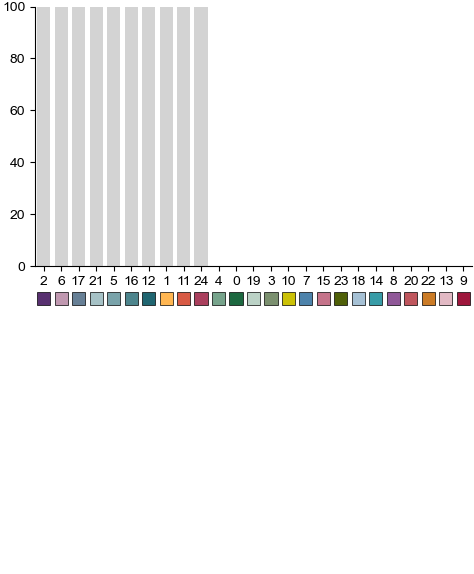

In [39]:
#Healthy controls only - to show they are only in HSPC-like clusters
#patient annotation representation in each cluster
fig, ax = plt.subplots(2,1, figsize = (5, 6))
ax = ax.ravel()

plot_cols = pat_colors_dict

for i, c in enumerate(lclusters):
    
        df = l_props_h.loc[(l_props_h['leiden']==c) & (l_props_h['patient_alias'].isin(['C1', 'C2', 'C3', 'C4', 'C5']))]
        # Sum of all proportions = total bar height
        total_height = df['proportion'].sum()
        #Turn df into a dictionary
        proportion_dict = dict(zip(df.patient_alias, df.proportion))
        #plot the bar graphs
        bottom = 0
        for category in ['C1', 'C2', 'C3', 'C4', 'C5']:
            height = proportion_dict.get(category, 0)
            color = plot_cols[category]
            ax[0].bar(i,
                     height,
                     bar_width,
                     bottom = bottom,
                     color = color)
            
            bottom += height #update bottom value for next plot

        # --- Add color squares above top row ---
        square_y = -15
        square_size = bar_width
        color = colors_dict.get(int(c), 'lightgrey')
        rect = mpatches.Rectangle(
            (i - square_size / 2, square_y),
            width=square_size,
            height=5,
            facecolor=color,
            edgecolor='k',
            lw=0.5,
            zorder=15,
            clip_on=False,
            transform=ax[0].transData
        )
        ax[0].add_patch(rect)

ax[0].set_ylim(0,100)
ax[0].set_xlim(-0.5, 24.5)
ax[0].set_xticks(np.arange(0,25, 1))
ax[0].set_xticklabels(lclusters)
ax[0].spines['top'].set_visible(False) 
ax[0].spines['right'].set_visible(False) 

# #Proxy artist for legend
# leg_pal = {}
# for m in ['P01', 'P03', 'P11', 'P12', 'P09', 'P17', 'P18',  'P02', 'P08']:
#     leg_pal[m] = plot_cols[m] 
# leg_pal['CON'] = plot_cols['C1'] #manually add in colour and label for controls
    
# handles = []
# f, a = plt.subplots()

# for lab in leg_pal.keys():
#     line = a.scatter([0], [0], label=lab, color=leg_pal[lab], marker = 's', s = 80,  linewidth = 1)
#     handles.append(line)    
# plt.close(f)

# ax[1].legend(handles = handles, labels = leg_pal.keys(), loc = 'upper center',bbox_to_anchor = [0.5,1], ncol = 14, columnspacing = 0.1, handletextpad=0.1, markerscale = 1)
ax[1].set_axis_off()


fig.tight_layout()
#fig.savefig('../Figures/1_Patient_annotation_leiden_barplots_controls_only_v2_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

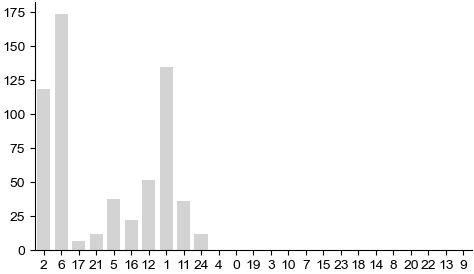

In [41]:
#Healthy controls with bars showing cell numbers
fig, ax = plt.subplots(figsize = (5, 3))


for i, c in enumerate(lclusters):
    height = h_num[c]
    color = plot_cols['C1']
    ax.bar(i,
             height,
             bar_width,
             color = color)

    # --- Add color squares above top row ---
    square_size = bar_width
    color = colors_dict.get(int(c), 'lightgrey')

#ax[0].set_ylim(0,100)
ax.set_xlim(-0.5, 24.5)
ax.set_xticks(np.arange(0,25, 1))
ax.set_xticklabels(lclusters)
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False) 


fig.tight_layout()
#fig.savefig('../Figures/1_Patient_annotation_leiden_barplots_controls_only_number_v2_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

In [43]:
#3. CITEseq ADT dotplot

In [45]:
#Read in protein data frommaster h5mu file
mdata = mu.read_h5ad('../Data/GEO_data_file_v1.h5mu', mod = 'protein')
mdata.var_names_make_unique()
mdata

AnnData object with n_obs × n_vars = 33853 × 272
    obs: 'capture_pool', 'patient_alias', 'time', 'leiden'
    layers: 'counts'

In [47]:
print(mdata.obs.shape)

(33853, 4)


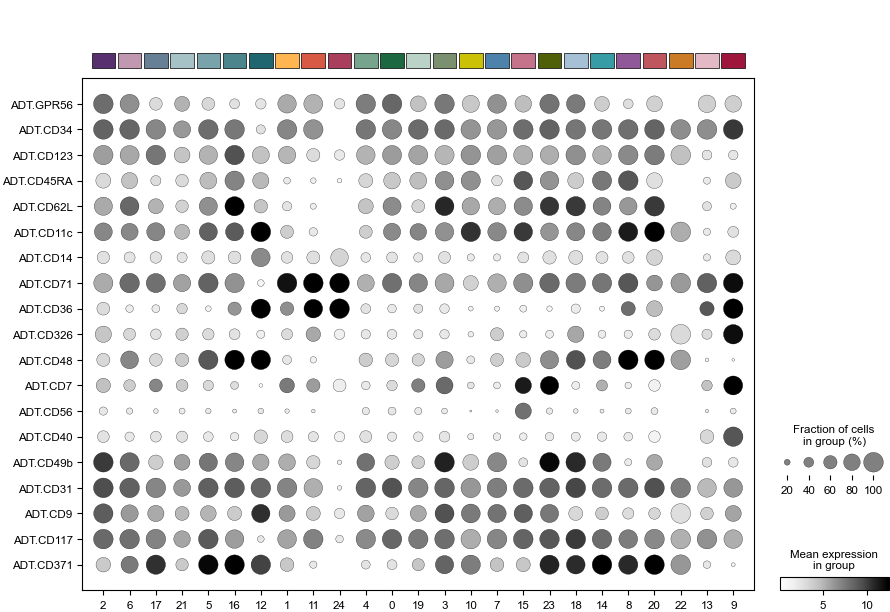

In [49]:
# Make a dotplot which shows the percentage of all cells positive for lineage defining and aberrant markers

markers = ['ADT.GPR56',
           'ADT.CD34',           
            'ADT.CD123',
            'ADT.CD45RA',   
            'ADT.CD62L',
           'ADT.CD11c',
           'ADT.CD14',   
            'ADT.CD71', 
            'ADT.CD36',
            'ADT.CD326',
            'ADT.CD48',    
            'ADT.CD7',
            'ADT.CD56',
            'ADT.CD40',
            'ADT.CD49b',
            'ADT.CD31',
            'ADT.CD9',
            'ADT.CD117',
            'ADT.CD371']


mdata_filtered = mdata[mdata.obs['leiden'].isin(lclusters)]

# Create dotplot (no fig/ax passed)
dot = sc.pl.dotplot(
    mdata_filtered,
    var_names=markers,
    groupby='leiden',
    categories_order=lclusters,
    cmap='Greys',
    expression_cutoff=2.5,
    vmax=12.5,
    swap_axes=True,
    show=False
)

# --- Handle both return types ---
if isinstance(dot, dict):
    axes = dot
    main_ax = axes.get('mainplot_ax', None)
    if main_ax is None:
        raise KeyError("Couldn't find 'mainplot_ax' in axes dict.")
    fig = main_ax.figure
else:
    axes = dot.get_axes()
    main_ax = axes['mainplot_ax']
    fig = main_ax.figure

# --- Rotate x tick labels ---
main_ax.set_xticklabels(main_ax.get_xticklabels(), rotation=0, ha='center')

# --- Get tick info ---
xticks = main_ax.get_xticks()
xticklabels = [t.get_text() for t in main_ax.get_xticklabels()]

# --- Add color squares above top row ---
ymin, ymax = main_ax.get_ylim()
square_y = ymax -1
square_size = 0.9

for x, label in zip(xticks, xticklabels):
    color = colors_dict.get(int(label), 'lightgrey')
    rect = mpatches.Rectangle(
        (x - square_size / 2, square_y),
        width=square_size,
        height=square_size/1.5,
        facecolor=color,
        edgecolor='k',
        lw=0.5,
        zorder=15,
        clip_on=False,
        transform=main_ax.transData
    )
    main_ax.add_patch(rect)

# --- Expand limits and figure space ---
fig.subplots_adjust(top=0.92, bottom=0.15, left=0.2, right=0.95)

#fig.savefig('../Figures/1_ADT_dotplot_leiden_clusters_all_markers_v2_GEO.pdf', dpi=600, bbox_inches=None, format = 'pdf')

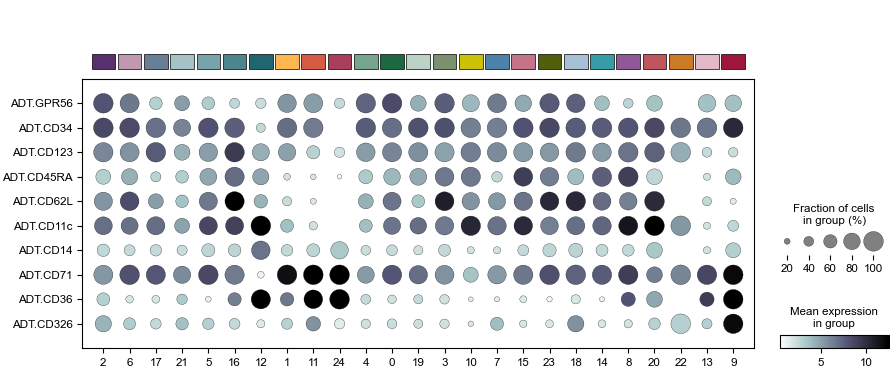

In [51]:
# Make a dotplot which shows the percentage of all cells positive for healthy lineage markers

markers = ['ADT.GPR56',
           'ADT.CD34',           
            'ADT.CD123',
            'ADT.CD45RA',   
            'ADT.CD62L',
           'ADT.CD11c',
           'ADT.CD14',   
            'ADT.CD71', 
            'ADT.CD36',
            'ADT.CD326'] #revisedset based on Lee Grimes paper Highly Consistent ADT (Fig 5j) except CD326 from the titration data shown in Fig2g and CD36 (from Henry originl set? marks ery and mono)

mdata_filtered = mdata[mdata.obs['leiden'].isin(lclusters)]

cmap = sns.color_palette("bone_r", as_cmap=True)

# Create dotplot (no fig/ax passed)
dot = sc.pl.dotplot(
    mdata_filtered,
    var_names=markers,
    groupby='leiden',
    categories_order=lclusters,
    cmap=cmap,
    expression_cutoff=2.5,
    vmax=12.5,
    swap_axes=True,
    show=False
)

# --- Handle both return types ---
if isinstance(dot, dict):
    axes = dot
    main_ax = axes.get('mainplot_ax', None)
    if main_ax is None:
        raise KeyError("Couldn't find 'mainplot_ax' in axes dict.")
    fig = main_ax.figure
else:
    axes = dot.get_axes()
    main_ax = axes['mainplot_ax']
    fig = main_ax.figure

# --- Rotate x tick labels ---
main_ax.set_xticklabels(main_ax.get_xticklabels(), rotation=0, ha='center')

# --- Get tick info ---
xticks = main_ax.get_xticks()
xticklabels = [t.get_text() for t in main_ax.get_xticklabels()]

# --- Add color squares above top row ---
ymin, ymax = main_ax.get_ylim()
square_y = ymax -1
square_size = 0.9

for x, label in zip(xticks, xticklabels):
    color = colors_dict.get(int(label), 'lightgrey')
    rect = mpatches.Rectangle(
        (x - square_size / 2, square_y),
        width=square_size,
        height=square_size/1.5,
        facecolor=color,
        edgecolor='k',
        lw=0.5,
        zorder=15,
        clip_on=False,
        transform=main_ax.transData
    )
    main_ax.add_patch(rect)

# --- Expand limits and figure space ---
fig.subplots_adjust(top=0.92, bottom=0.15, left=0.2, right=0.95)

#fig.savefig('../Figures/1_ADT_dotplot_leiden_clusters_healthy_markers_v2_GEO.pdf', dpi=600, bbox_inches=None, format = 'pdf')

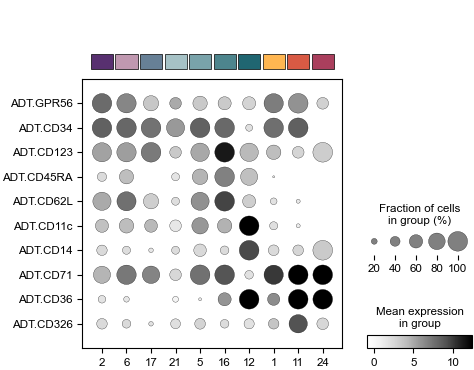

In [53]:
# Make a dotplot which shows the percentage of all cells positive for healthy lineage markers in healthy donors

# Define the antibody markers to plot
markers = ['ADT.GPR56',
           'ADT.CD34',           
            'ADT.CD123',
            'ADT.CD45RA',   
            'ADT.CD62L',
           'ADT.CD11c',
           'ADT.CD14',   
            'ADT.CD71', 
            'ADT.CD36',
            'ADT.CD326'] 

mdata_filtered = mdata[(mdata.obs['leiden'].isin(['2','6','17','21','5','16','12', '1','11','24'])) & mdata.obs['patient_alias'].isin(['C1', 'C2', 'C3', 'C4', 'C5'])] #healthy clusters, control donors

# Create dotplot (no fig/ax passed)
dot = sc.pl.dotplot(
    mdata_filtered,
    var_names=markers,
    groupby='leiden',
    categories_order=['2','6','17','21','5','16','12', '1','11','24'],
    cmap='Greys',
    expression_cutoff=2.5,
    vmax=12.5,
    swap_axes=True,
    show=False
)

# --- Handle both return types ---
if isinstance(dot, dict):
    axes = dot
    main_ax = axes.get('mainplot_ax', None)
    if main_ax is None:
        raise KeyError("Couldn't find 'mainplot_ax' in axes dict.")
    fig = main_ax.figure
else:
    axes = dot.get_axes()
    main_ax = axes['mainplot_ax']
    fig = main_ax.figure

# --- Rotate x tick labels ---
main_ax.set_xticklabels(main_ax.get_xticklabels(), rotation=0, ha='center')

# --- Get tick info ---
xticks = main_ax.get_xticks()
xticklabels = [t.get_text() for t in main_ax.get_xticklabels()]

# --- Add color squares above top row ---
ymin, ymax = main_ax.get_ylim()
square_y = ymax -1
square_size = 0.9

for x, label in zip(xticks, xticklabels):
    color = colors_dict.get(int(label), 'lightgrey')
    rect = mpatches.Rectangle(
        (x - square_size / 2, square_y),
        width=square_size,
        height=square_size/1.5,
        facecolor=color,
        edgecolor='k',
        lw=0.5,
        zorder=15,
        clip_on=False,
        transform=main_ax.transData
    )
    main_ax.add_patch(rect)

# --- Expand limits and figure space ---
fig.subplots_adjust(top=0.92, bottom=0.15, left=0.2, right=0.95)

#fig.savefig('../Figures/1_ADT_dotplot_leiden_clusters_healthy_markers_controls_v2_GEO.pdf', dpi=600, bbox_inches=None, format = 'pdf')

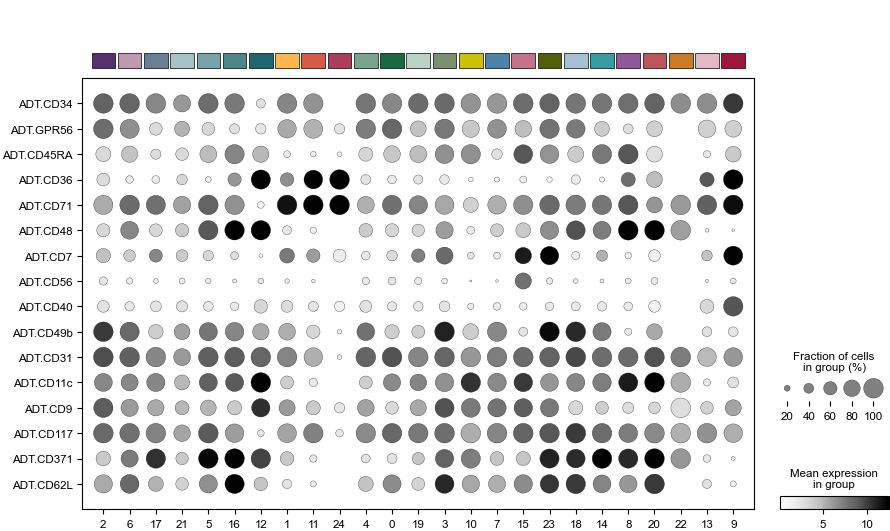

In [55]:
# Make a dotplot which shows the percentage of all cells positive atypical cluster defining markers

# Define the antibody markers to plot
markers = ['ADT.CD34',
            'ADT.GPR56',
            'ADT.CD45RA',   
            'ADT.CD36',
            'ADT.CD71',
            'ADT.CD48',
            'ADT.CD7',
            'ADT.CD56',
            'ADT.CD40',
            'ADT.CD49b',
            'ADT.CD31',
            'ADT.CD11c',
            'ADT.CD9',
            'ADT.CD117',
            'ADT.CD371',
            'ADT.CD62L'] #Revise order to match healthyier markers

mdata_filtered = mdata[mdata.obs['leiden'].isin(lclusters)]

# Create dotplot (no fig/ax passed)
dot = sc.pl.dotplot(
    mdata_filtered,
    var_names=markers,
    groupby='leiden',
    categories_order=lclusters,
    cmap='Greys',
    expression_cutoff=2.5,
    vmax=12.5,
    swap_axes=True,
    show=False
)

# --- Handle both return types ---
if isinstance(dot, dict):
    axes = dot
    main_ax = axes.get('mainplot_ax', None)
    if main_ax is None:
        raise KeyError("Couldn't find 'mainplot_ax' in axes dict.")
    fig = main_ax.figure
else:
    axes = dot.get_axes()
    main_ax = axes['mainplot_ax']
    fig = main_ax.figure

# --- Rotate x tick labels ---
main_ax.set_xticklabels(main_ax.get_xticklabels(), rotation=0, ha='center')

# --- Get tick info ---
xticks = main_ax.get_xticks()
xticklabels = [t.get_text() for t in main_ax.get_xticklabels()]

# --- Add color squares above top row ---
ymin, ymax = main_ax.get_ylim()
square_y = ymax -1
square_size = 0.9

for x, label in zip(xticks, xticklabels):
    color = colors_dict.get(int(label), 'lightgrey')
    rect = mpatches.Rectangle(
        (x - square_size / 2, square_y),
        width=square_size,
        height=square_size/1.5,
        facecolor=color,
        edgecolor='k',
        lw=0.5,
        zorder=15,
        clip_on=False,
        transform=main_ax.transData
    )
    main_ax.add_patch(rect)

# --- Expand limits and figure space ---
fig.subplots_adjust(top=0.92, bottom=0.15, left=0.2, right=0.95)

#fig.savefig('../Figures/1_ADT_dotplot_leiden_clusters_atypical_markers_v2_GEO.pdf', dpi=600, bbox_inches=None, format = 'pdf')

In [57]:
#4. Sample pooling plots

In [61]:
#Import pooling data
pool = pd.read_excel('../Data/Pooling_sankey.xlsx')
pool

,target,source,PID,Timepoint,value
0,HSPC_Pool4,C5,C5,NaN,1
1,Pool6,C5,C5,NaN,1
2,HSPC_Pool4,C4,C4,NaN,1
3,Pool3,C4,C4,NaN,1
4,HSPC_Pool3,C3,C3,NaN,1
...,...,...,...,...,...
57,Pool2,P01_End,P01,C12D29,1
58,HSPC_Pool2,P01_C7,P01,C7D1,1
59,Pool1,P01_C7,P01,C7D1,1
60,HSPC_Pool1,P01_Dx,P01,C1D1,1


In [63]:
#Update color dictionaries to include alpha versions for timepoints
#Now add in alpha versions for timepoints, also add pool colours
def apply_alpha_to_hex(hex_color, alpha, background='#ffffff'):
    """Return the hex value of a color after applying alpha over a background."""
    # Convert hex to RGB
    rgb = mcolors.to_rgb(hex_color)
    bg_rgb = mcolors.to_rgb(background)

    # Blend the foreground color with the background using alpha
    blended_rgb = [
        (1 - alpha) * bg + alpha * fg
        for fg, bg in zip(rgb, bg_rgb)
    ]
    
    # Convert back to hex
    return mcolors.to_hex(blended_rgb)


for s in pool['source'].drop_duplicates().to_list():
    if s in ['C1', 'C2', 'C3', 'C4', 'C5']:
        continue
    else:
        p = s.split('_')[0]
        t = s.split('_')[1]
        if t == 'Dx':
            pat_colors_dict2[s] = apply_alpha_to_hex(pat_colors_dict[p], 1) #make 0.6 for timepoint specific colours
        elif t == 'C7':
            pat_colors_dict2[s] = apply_alpha_to_hex(pat_colors_dict[p], 1)
        elif t == 'End':
            pat_colors_dict2[s] = apply_alpha_to_hex(pat_colors_dict[p], 1) #make 0.8 for timepoint specific colours

for k,v in batch_colors_dict.items():
    pat_colors_dict2[k] = v

#Some values are missing - add manually
pat_colors_dict2['HSPC_Pool4'] = pat_colors_dict2['HSPC_pool4']
pat_colors_dict2['HSPC_Pool3'] = pat_colors_dict2['HSPC_pool3_repeat']
pat_colors_dict2['HSPC_Pool1'] = pat_colors_dict2['HSPC_pool1']
pat_colors_dict2['HSPC_Pool2'] = pat_colors_dict2['HSPC_pool2']
pat_colors_dict2['Pool5'] = pat_colors_dict2['Pool5_repeat']

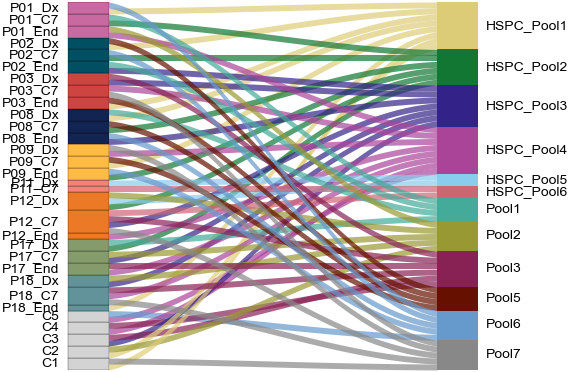

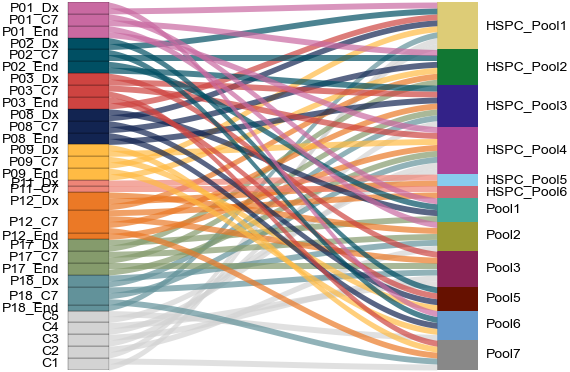

In [65]:
#Plot the custom sankey plots

# --- Customisable node order ---
left_order  = ['C1', 'C2', 'C3', 'C4', 'C5', 'P18_End', 'P18_C7', 'P18_Dx',
               'P17_End', 'P17_C7', 'P17_Dx', 'P12_End', 'P12_C7', 'P12_Dx',
                          'P11_C7',  'P11_Dx','P09_End', 'P09_C7', 'P09_Dx',
               'P08_End', 'P08_C7', 'P08_Dx', 'P03_End', 'P03_C7', 'P03_Dx',
               'P02_End', 'P02_C7', 'P02_Dx','P01_End', 'P01_C7', 'P01_Dx'] #listed bottom to top (reverse list if in other orientation)

right_order = list(reversed(['HSPC_Pool1', 'HSPC_Pool2','HSPC_Pool3','HSPC_Pool4','HSPC_Pool5', 'HSPC_Pool6','Pool1', 'Pool2',  'Pool3',  'Pool5',  'Pool6', 'Pool7'])) #listed top to bottom

# --- Layout options ---
MATCH_HEIGHTS = True      # True = scale both sides to same height
CENTER_SMALLER = True     # If MATCH_HEIGHTS=False, center shorter side
ribbon_curve = 0.8        # 0 = straight, 1 = fully curved
bow_strength = 0        # 0 = no bow, 1 = strong mid-arch
pad_width = 0.1          # fixed width of left/right bars

# --- Helper to compute stacked node positions ---
def compute_positions(values: dict, order=None, scale_factor=1.0, offset=0.0):
    if not isinstance(values, dict):
        values = dict(values)
    if order is not None:
        values = {k: values[k] for k in order if k in values}

    total_val = builtins.sum(values.values())
    if total_val == 0:
        raise ValueError("Sum of node values is zero.")

    y0 = offset
    positions = {}
    for label, val in values.items():
        y1 = y0 + (val / total_val) * scale_factor
        positions[label] = (y0, y1)
        y0 = y1
    return positions

# --- Compute totals ---
left_totals = pool.groupby("source")["value"].sum().to_dict()
right_totals = pool.groupby("target")["value"].sum().to_dict()

left_total_sum = builtins.sum(left_totals.values())
right_total_sum = builtins.sum(right_totals.values())

# --- Compute scaling or centering ---
if MATCH_HEIGHTS:
    max_total = max(left_total_sum, right_total_sum)
    left_scale = max_total / left_total_sum if left_total_sum > 0 else 1.0
    right_scale = max_total / right_total_sum if right_total_sum > 0 else 1.0
    left_offset = 0.0
    right_offset = 0.0
else:
    left_scale = right_scale = 1.0
    max_total = max(left_total_sum, right_total_sum)
    if CENTER_SMALLER:
        left_offset = (max_total - left_total_sum) / (2 * max_total) if left_total_sum < max_total else 0.0
        right_offset = (max_total - right_total_sum) / (2 * max_total) if right_total_sum < max_total else 0.0
    else:
        left_offset = right_offset = 0.0

# --- Compute node positions ---
left_pos = compute_positions(left_totals, order=left_order, scale_factor=left_scale, offset=left_offset)
right_pos = compute_positions(right_totals, order=right_order, scale_factor=right_scale, offset=right_offset)


for src_col_ribbon in [False, True]:  #makes plots highlighting either source or target
    # --- Setup figure ---
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis("off")
    
    # --- Draw left and right bars ---
    for label, (y0, y1) in left_pos.items():
        ax.add_patch(mpatches.Rectangle((0, y0), pad_width, (y1 - y0),
                                       facecolor=pat_colors_dict2.get(label, "gray"),
                                       edgecolor="k", linewidth=0.2))
        ax.text(-0.02, (y0 + y1) / 2, label, va="center", ha="right", fontsize=10)
    
    for label, (y0, y1) in right_pos.items():
        ax.add_patch(mpatches.Rectangle((1 - pad_width, y0), pad_width, y1 - y0,
                                       facecolor=pat_colors_dict2.get(label, "gray"),
                                       edgecolor="none", linewidth=0.2))
        ax.text(1.02, (y0 + y1) / 2, label, va="center", ha="left", fontsize=10)
    
    # --- Track offsets for ribbons ---
    left_offsets = {k: 0 for k in left_pos}
    right_offsets = {k: 0 for k in right_pos}
    
    # --- Draw curved ribbons with mid-bow ---
    for _, row in pool.iterrows():
        src, tgt, val = row["source"], row["target"], row["value"]
        if src not in left_pos or tgt not in right_pos:
            continue
    
        y0_start, y0_end = left_pos[src]
        y1_start, y1_end = right_pos[tgt]
    
        total_left = left_totals[src]
        total_right = right_totals[tgt]
    
        y0a = y0_start + left_offsets[src] / total_left * (y0_end - y0_start)
        y0b = y0a + val / total_left * (y0_end - y0_start)
        y1a = y1_start + right_offsets[tgt] / total_right * (y1_end - y1_start)
        y1b = y1a + val / total_right * (y1_end - y1_start)
    
        left_offsets[src] += val
        right_offsets[tgt] += val
    
        xs = np.linspace(pad_width, 1 - pad_width, 100)
        t = (xs - pad_width) / (1 - 2*pad_width)  # normalize 0→1 across ribbons
        # cubic easing for smooth curve
        curve = 3*t**2 - 2*t**3
        # interpolate straight vs curved
        ys_top = y0b + (y1b - y0b) * (curve * ribbon_curve + t * (1 - ribbon_curve))
        ys_bottom = y0a + (y1a - y0a) * (curve * ribbon_curve + t * (1 - ribbon_curve))
        # apply mid-bow
        bow = (np.sin(np.pi * t) * bow_strength * (y1b - y0b))
        ys_top += bow
        ys_bottom += bow
    
        if src_col_ribbon == True:    
            l = 'src'
            ax.fill_between(xs, ys_bottom, ys_top,
                        color=pat_colors_dict2.get(src, "gray"),
                        alpha=0.7, linewidth=0)
        else:
            l='tgt'
            ax.fill_between(xs, ys_bottom, ys_top,
                color=pat_colors_dict2.get(tgt, "gray"),
                alpha=0.7, linewidth=0)
    
    # --- Layout & export ---
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(0, 1)
    fig.tight_layout()
    
    #fig.savefig(f'../Figures/1_Pooling_sankey_{l}_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)


In [67]:
#5. UMAPs with different colour overlays
#Have moved to a second notebook because the pdf setting used to make barplots editable make the UMAP plots ridiculously large

In [69]:
#6. Batch contribution barplot

In [71]:
#batch proportion per cluster
b_props = None

 
for c in lclusters:
    dfb = adata_all.loc[adata_all['leiden'] == c]
    
    # Calculate proportions of each cell type
    #df = pd.DataFrame(dfb['new_dataset'].value_counts(normalize=True) * 100).reset_index()
    df = pd.DataFrame(dfb['capture_pool'].value_counts(normalize=True) * 100).reset_index() #slghtly different name in new version
    df['leiden'] = c


    if b_props is None:
        b_props = df.copy()
    else:
        b_props = pd.concat([b_props, df],ignore_index = True)

#b_props

#less rows (by 50) cf other file version - seems to be because old version contains HSPC pool 5/6 and the hashtag names. Hashtag names have no data, output is the same
b_props

,capture_pool,proportion,leiden
0,HSPC_pool1,45.880731,2
1,HSPC_pool4,37.642192,2
2,HSPC_pool2,10.582558,2
3,HSPC_pool3_repeat,4.550155,2
4,HSPC_Pool6,0.551534,2
...,...,...,...
295,Pool1,0.000000,9
296,Pool2,0.000000,9
297,Pool3,0.000000,9
298,Pool5_repeat,0.000000,9


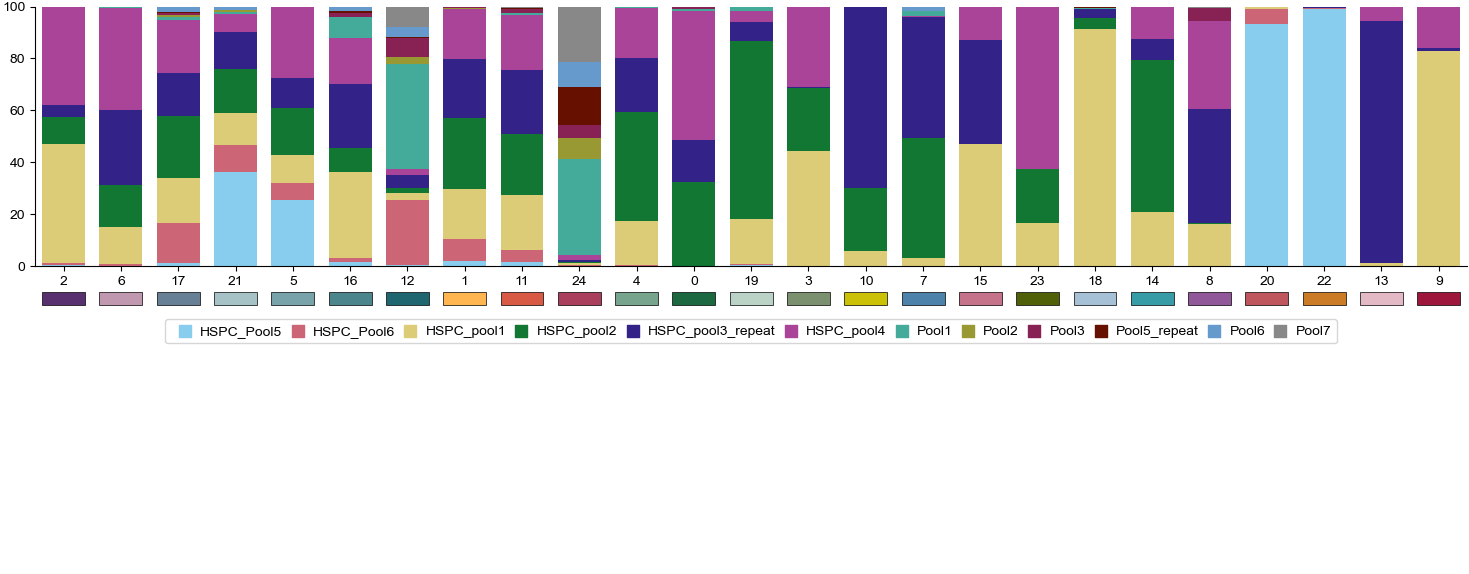

In [73]:
#devcell annotation representation in each cluster
fig, ax = plt.subplots(2,1, figsize = (15, 6))
ax = ax.ravel()

plot_cols = batch_colors_dict

for i, c in enumerate(lclusters):
    
        df = b_props.loc[(b_props['leiden']==c)]
        # Sum of all proportions = total bar height
        total_height = df['proportion'].sum()
        #Turn df into a dictionary
        proportion_dict = dict(zip(df.capture_pool, df.proportion))
        #plot the bar graphs
        bottom = 0
        for category in batch_colors_dict.keys(): 
            height = proportion_dict.get(category, 0)
            color = plot_cols[category]
            ax[0].bar(i,
                     height,
                     bar_width,
                     bottom = bottom,
                     color = color)
            
            bottom += height #update bottom value for next plot
            
        # --- Add color squares above top row ---
        square_y = -15
        square_size = bar_width
        color = colors_dict.get(int(c), 'lightgrey')
        rect = mpatches.Rectangle(
            (i - square_size / 2, square_y),
            width=square_size,
            height=5,
            facecolor=color,
            edgecolor='k',
            lw=0.5,
            zorder=15,
            clip_on=False,
            transform=ax[0].transData
        )
        ax[0].add_patch(rect)

ax[0].set_ylim(0,100)
ax[0].set_xlim(-0.5, 24.5)
ax[0].set_xticks(np.arange(0,25, 1))
ax[0].set_xticklabels(lclusters)
ax[0].spines['top'].set_visible(False) 
ax[0].spines['right'].set_visible(False) 

#Proxy artist for legend
leg_pal = {}
for m in batch_colors_dict.keys():
    leg_pal[m] = plot_cols[m] 
    
handles = []
f, a = plt.subplots()

for lab in leg_pal.keys():
    line = a.scatter([0], [0], label=lab, color=leg_pal[lab], marker = 's', s = 80,  linewidth = 1)
    handles.append(line)    
plt.close(f)

ax[1].legend(handles = handles, labels = leg_pal.keys(), loc = 'upper center',bbox_to_anchor = [0.5,1], ncol = 14, columnspacing = 0.1, handletextpad=0.1, markerscale = 1)
ax[1].set_axis_off()

fig.tight_layout()
#fig.savefig('../Figures/1_Batch_annotation_leiden_barplots_v2_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

In [75]:
#Trying an alternate visualisation for the patient/cluster annotations
hm_df = adata.obs[['patient_alias', 'leiden']]

hm_df['leiden'] = hm_df['leiden'].astype(pd.CategoricalDtype(ordered=True, categories=lclusters))
hm_df['patient_alias'] = hm_df['patient_alias'].astype(pd.CategoricalDtype(ordered=True, categories=['C1', 'C2', 'C3', 'C4', 'C5','P01', 'P03', 'P11', 'P12', 'P09', 'P17', 'P18',  'P02', 'P08']))

C:\Users\z3283497\AppData\Local\Temp\ipykernel_48928\265973587.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hm_df['leiden'] = hm_df['leiden'].astype(pd.CategoricalDtype(ordered=True, categories=lclusters))
C:\Users\z3283497\AppData\Local\Temp\ipykernel_48928\265973587.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hm_df['patient_alias'] = hm_df['patient_alias'].astype(pd.CategoricalDtype(ordered=True, categories=['C1', 'C2', 'C3', 'C4', 'C5','P01', 'P03', 'P11', 'P12', 'P09', 'P17', 'P18',  'P02

In [77]:
counts = pd.crosstab(hm_df['patient_alias'], hm_df['leiden']) #Rearranged table
counts_with_total = counts.assign(_Total=counts.sum(axis=1)) # Add a per-patient total column
row_props = counts.div(counts.sum(axis=1), axis=0) # Get row-wise percentages for each patient (sums to 1 per row)
#row_props

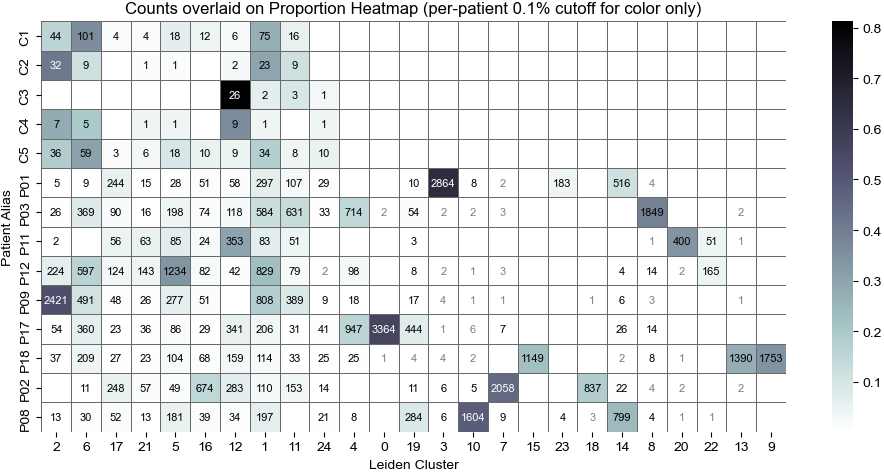

In [79]:
# Compute per-patient thresholds
row_totals = counts.sum(axis=1)
t = 0.1 #(% threshold)
thresholds = (t/100) * row_totals  # 1% of each patient's total cells


# Mask only color (not text) for cells below threshold
masked = row_props.copy()
for patient in masked.index:
    masked.loc[patient] = np.where(
        counts.loc[patient] < thresholds[patient], np.nan, masked.loc[patient]
    )

# Create colormap
cmap = sns.color_palette("bone_r", as_cmap=True)
#cmap = sns.color_palette("afmhot_r", as_cmap=True)
#cmap = sns.color_palette("YlOrBr", as_cmap=True)
#cmap = sns.color_palette("grey_r", as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 5))

# Heatmap: white where masked, colored elsewhere
sns.heatmap(
    masked,
    cmap=cmap,
    linewidths=0.5,
    linecolor='dimgray',
    cbar=True,
    mask=masked.isna(),
    ax=ax
)

# Add counts everywhere — but color adaptively only for non-masked cells
mesh = ax.collections[0]
vmin, vmax = mesh.get_clim()
norm = Normalize(vmin=vmin, vmax=vmax)

for i in range(row_props.shape[0]):
    for j in range(row_props.shape[1]):
        prop = row_props.iat[i, j]
        cnt = counts.iat[i, j]
        patient = row_props.index[i]
        # Always display the count, even if below threshold
        if cnt == 0:
            continue

        if counts.loc[patient, row_props.columns[j]] < thresholds[patient]:
            # Below threshold → white cell, black text
            txt_color = 'grey'
        else:
            # Above threshold → color cell, adaptive text color
            r, g, b, _ = cmap(norm(prop))
            luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
            txt_color = 'black' if luminance > 0.5 else 'white'

        ax.text(
            j + 0.5, i + 0.5, f"{cnt}",
            ha='center', va='center',
            fontsize=8, color=txt_color
        )

ax.set_xlabel("Leiden Cluster")
ax.set_ylabel("Patient Alias")
ax.set_title(f"Counts overlaid on Proportion Heatmap (per-patient {t}% cutoff for color only)")
fig.tight_layout()

#fig.savefig('../Figures/1_Patient_leiden_heatmap_v2_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

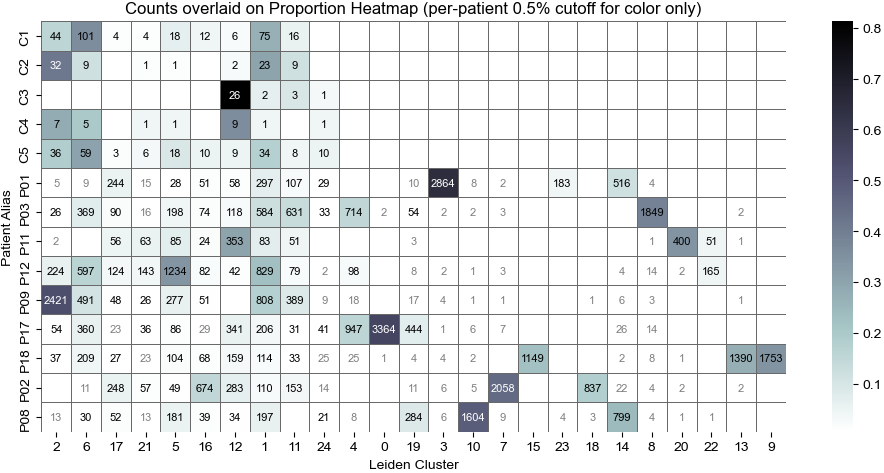

In [80]:
# Compute per-patient thresholds - adjusted color palette


# Base colormap
base_cmap = sns.color_palette("bone_r", as_cmap=True)

row_totals = counts.sum(axis=1)
t = 0.5#(% threshold)
val_threshold = t / 100  # convert to [0,1] scale
thresholds = (t/100) * row_totals  # 1% of each patient's total cells

# Sample the original colormap only for values above threshold
n = 256
colors = base_cmap(np.linspace(val_threshold, 1, n))
# Prepend white for values below threshold
colors = np.vstack((np.ones((int(n * val_threshold), 4)), colors))

# Create a new colormap
cmap = LinearSegmentedColormap.from_list("bone_r_thresholded", colors)



# Mask only color (not text) for cells below threshold
masked = row_props.copy()
for patient in masked.index:
    masked.loc[patient] = np.where(
        counts.loc[patient] < thresholds[patient], np.nan, masked.loc[patient]
    )



fig, ax = plt.subplots(figsize=(10, 5))

# Heatmap: white where masked, colored elsewhere
sns.heatmap(
    masked,
    cmap=cmap,
    linewidths=0.5,
    linecolor='dimgray',
    cbar=True,
    mask=masked.isna(),
    ax=ax
)

# Add counts everywhere — but color adaptively only for non-masked cells
mesh = ax.collections[0]
vmin, vmax = mesh.get_clim()
norm = Normalize(vmin=vmin, vmax=vmax)

for i in range(row_props.shape[0]):
    for j in range(row_props.shape[1]):
        prop = row_props.iat[i, j]
        cnt = counts.iat[i, j]
        patient = row_props.index[i]
        # Always display the count, even if below threshold
        if cnt == 0:
            continue

        if counts.loc[patient, row_props.columns[j]] < thresholds[patient]:
            # Below threshold → white cell, black text
            txt_color = 'grey'
        else:
            # Above threshold → color cell, adaptive text color
            r, g, b, _ = cmap(norm(prop))
            luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
            txt_color = 'black' if luminance > 0.5 else 'white'

        ax.text(
            j + 0.5, i + 0.5, f"{cnt}",
            ha='center', va='center',
            fontsize=8, color=txt_color
        )

ax.set_xlabel("Leiden Cluster")
ax.set_ylabel("Patient Alias")
ax.set_title(f"Counts overlaid on Proportion Heatmap (per-patient {t}% cutoff for color only)")
fig.tight_layout()

#fig.savefig('../Figures/1_Patient_leiden_heatmap_cmap_v2_GEO.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)